# 1. 什么是张量
张量是一个多维数组，可以是标量、向量、矩阵或更高维度的数据结构。储存同一元素的容器，且元素必须是数值才可以。

在 PyTorch 中，张量（Tensor）是数据的核心表示形式，类似于 NumPy 的多维数组，但具有更强大的功能，例如支持 GPU 加速和自动梯度计算。

张量支持多种数据类型（整型、浮点型、布尔型等）。

张量可以存储在 CPU 或 GPU 中，GPU 张量可显著加速计算。

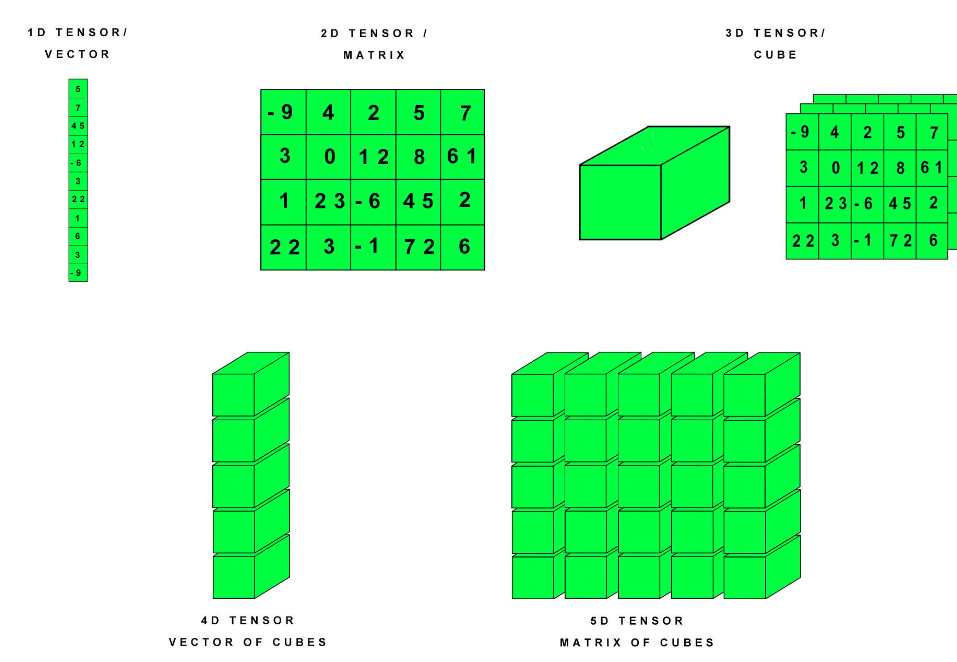

# 2. 张量的创建的方式

    方法	说明	示例代码
    torch.tensor(data)	从 Python 列表或 NumPy 数组创建张量。	x = torch.tensor([[1, 2], [3, 4]])
    torch.zeros(size)	创建一个全为零的张量。	x = torch.zeros((2, 3))
    torch.ones(size)	创建一个全为 1 的张量。	x = torch.ones((2, 3))
    torch.empty(size)	创建一个未初始化的张量。	x = torch.empty((2, 3))
    torch.rand(size)	创建一个服从均匀分布的随机张量，值在 [0, 1)。	x = torch.rand((2, 3))
    torch.randn(size)	创建一个服从正态分布的随机张量，均值为 0，标准差为 1。	x = torch.randn((2, 3))
    torch.arange(start, end, step)	创建一个一维序列张量，类似于 Python 的 range。	x = torch.arange(0, 10, 2)
    torch.linspace(start, end, steps)	创建一个在指定范围内等间隔的序列张量。	x = torch.linspace(0, 1, 5)
    torch.eye(size)	创建一个单位矩阵（对角线为 1，其他为 0）。	x = torch.eye(3)
    torch.from_numpy(ndarray)	将 NumPy 数组转换为张量。	x = torch.from_numpy(np.array([1, 2, 3]))

## (1) 基本创建方式
- torch.tensor -- 根据指定数据创建张量
- troch.Tensor -- 根据形状创建张量，其也可以用来创建指定数据的张量
- torch.IntTensor, torch.FloatTensor, torch.DoubleTensor  -- 创建指定类型的张量

细节：Tensor 方式较于 tensor 方式，可以基于形状来直接创建张量

需要掌握函数：
arange(), linspace(), manual_seed(), randint()

tensor(值，类型)

In [1]:
import torch
import numpy as np

In [2]:
# 1. torch.tensor 
def dm01():
    # scene 1: 标量  -> 张量
    t1 = torch.tensor(10)
    print(f't1:{t1}, type:{type(t1)}')
    print('-'*30)

    # scene 2: 二维列表 -> 张量
    data = [[1, 2, 3], [4, 5, 6]]
    t2 = torch.tensor(data)
    print(f't2:{t2}, type:{type(t2)}')
    print('-'*30)

    # scene 3: numpy nd数组 -> 张量
    data = np.random.randint(0, 10, size = (2, 3))
    t3 = torch.tensor(data, dtype=torch.float)    # 可指定数据类型
    print(f't3:{t3}, type:{type(t3)}')
    print('-'*30)

    # scene 4: 尝试直接创建， 指定维度（例如：2行3列）张量
    # t4 = torch.tensor(2, 3)                             # 报错
    # print(f't4:{t4}, type:{type(t4)}')

In [3]:
dm01()

t1:10, type:<class 'torch.Tensor'>
------------------------------
t2:tensor([[1, 2, 3],
        [4, 5, 6]]), type:<class 'torch.Tensor'>
------------------------------
t3:tensor([[0., 0., 8.],
        [4., 8., 7.]]), type:<class 'torch.Tensor'>
------------------------------


In [4]:
# 2. torch.Tensor 
def dm02():
    # scene 1: 标量  -> 张量
    t1 = torch.Tensor(10)
    print(f't1:{t1}, type:{type(t1)}')
    print('-'*30)

    # scene 2: 二维列表 -> 张量
    data = [[1, 2, 3], [4, 5, 6]]
    t2 = torch.Tensor(data)
    print(f't2:{t2}, type:{type(t2)}')
    print('-'*30)

    # scene 3: numpy nd数组 -> 张量
    data = np.random.randint(0, 10, size = (2, 3))
    t3 = torch.Tensor(data)                            # 不可使用类型
    print(f't3:{t3}, type:{type(t3)}')
    print('-'*30)

    # scene 4: 尝试直接创建， 指定维度（例如：2行3列）张量
    t4 = torch.Tensor(2, 3)
    print(f't4:{t4}, type:{type(t4)}')

In [5]:
dm02()

t1:tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), type:<class 'torch.Tensor'>
------------------------------
t2:tensor([[1., 2., 3.],
        [4., 5., 6.]]), type:<class 'torch.Tensor'>
------------------------------
t3:tensor([[5., 5., 6.],
        [1., 1., 2.]]), type:<class 'torch.Tensor'>
------------------------------
t4:tensor([[4.1343e-28, 1.7222e-42, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00]]), type:<class 'torch.Tensor'>


In [6]:
def dm03():
    # scene 1: 标量  -> 张量
    t1 = torch.IntTensor(10)
    print(f't1:{t1}, type:{type(t1)}')
    print('-'*30)

    # scene 2: 二维列表 -> 张量
    data = [[1, 2, 3], [4, 5, 6]]
    t2 = torch.IntTensor(data)
    print(f't2:{t2}, type:{type(t2)}')
    print('-'*30)

    # scene 3: numpy nd数组 -> 张量
    data = np.random.randint(0, 10, size = (2, 3))
    t3 = torch.IntTensor(data)    
    print(f't3:{t3}, type:{type(t3)}')
    print('-'*30)

    # scene 4: 如果类型不匹配，会尝试自动转换类型
    data = np.random.randint(0, 10, size = (2, 3))
    t4 = torch.FloatTensor(data)      # 默认： float32. （张量） 
    print(f't3:{t4}, type:{type(t4)}')
    print('-'*30)

In [7]:
dm03()

t1:tensor([302122224,      1229,         0,         0,         0,         0,
                0,         0,         0,         0], dtype=torch.int32), type:<class 'torch.Tensor'>
------------------------------
t2:tensor([[1, 2, 3],
        [4, 5, 6]], dtype=torch.int32), type:<class 'torch.Tensor'>
------------------------------
t3:tensor([[6, 3, 7],
        [2, 2, 6]], dtype=torch.int32), type:<class 'torch.Tensor'>
------------------------------
t3:tensor([[3., 4., 7.],
        [3., 5., 9.]]), type:<class 'torch.Tensor'>
------------------------------


## （2） 创建0、1 指定值张量
- torch.ones 和 torch.ones_like 创建全1张量
- torch.zeros 和 torch.zeros_like 创建0张量
- torch.full 和 torch.full_like 创建全为指定值张量

需要掌握的函数：

zeros(), full()

In [8]:
import torch
import numpy as np

In [9]:
import torch
# scene 1：torch.ones 和 torch.ones_like
t1 = torch.ones(2, 3)   # 创建2行3列全1张量
print(f't1:{t1}, type:{type(t1)}')
print('-'*30)

# t2: 3行2列
t2 = torch.tensor([[1, 2],[3, 4], [5, 6]])
print(f't2:{t2}, type:{type(t2)}')
print('-'*30)

# t3 -> 基于t2的形状，创建全1张量
t3 = torch.ones_like(t2)
print(f't3:{t3}, type:{type(t3)}')     # 3行2列  -> 全1矩阵

t1:tensor([[1., 1., 1.],
        [1., 1., 1.]]), type:<class 'torch.Tensor'>
------------------------------
t2:tensor([[1, 2],
        [3, 4],
        [5, 6]]), type:<class 'torch.Tensor'>
------------------------------
t3:tensor([[1, 1],
        [1, 1],
        [1, 1]]), type:<class 'torch.Tensor'>


In [10]:
# scene 2：torch.zeros 和 torch.zeros_like
t1 = torch.zeros(2, 3)   # 创建2行3列全0张量
print(f't1:{t1}, type:{type(t1)}')
print('-'*30)

# t2: 3行2列
t2 = torch.tensor([[1, 2],[3, 4], [5, 6]])
print(f't2:{t2}, type:{type(t2)}')
print('-'*30)

# t3 -> 基于t2的形状，创建全0张量
t3 = torch.zeros_like(t2)
print(f't3:{t3}, type:{type(t3)}')     # 3行2列  -> 全0矩阵

t1:tensor([[0., 0., 0.],
        [0., 0., 0.]]), type:<class 'torch.Tensor'>
------------------------------
t2:tensor([[1, 2],
        [3, 4],
        [5, 6]]), type:<class 'torch.Tensor'>
------------------------------
t3:tensor([[0, 0],
        [0, 0],
        [0, 0]]), type:<class 'torch.Tensor'>


In [11]:
# scene 3：torch.full 和 torch.full_like 创建为指定张量
t1 = torch.full(size = (2, 3), fill_value=255)   # 创建2行3列全255张量
print(f't1:{t1}, type:{type(t1)}')
print('-'*30)

# t2: 3行2列
t2 = torch.tensor([[1, 2],[3, 4], [5, 6]])
print(f't2:{t2}, type:{type(t2)}')
print('-'*30)

# t3 -> 基于t2的形状，创建全255张量
t3 = torch.full_like(t2, fill_value=255)
print(f't3:{t3}, type:{type(t3)}')     # 3行2列  -> 全255矩阵

t1:tensor([[255, 255, 255],
        [255, 255, 255]]), type:<class 'torch.Tensor'>
------------------------------
t2:tensor([[1, 2],
        [3, 4],
        [5, 6]]), type:<class 'torch.Tensor'>
------------------------------
t3:tensor([[255, 255],
        [255, 255],
        [255, 255]]), type:<class 'torch.Tensor'>


## （3） 创建线性和随机张量
- torch.arange() 和 torch.linspace()  -- 创建线性张量
- torch.random.initial_seed() 和 torch.random.manual_seed()  -- 随机种子
- torch.rand/randn()  创建随机浮点类型张量
- torch.randint(low, high, size()) -- 创建随机整数类型张量

掌握的函数：
arange(), linspace(), manual_seed(), randint()

In [12]:
import torch

In [13]:
# 1. 创建线性张量
def dm04():
    # scene 1: 创建指定范围的 线性增量
    t1 = torch.arange(1, 10, 2)        # 参1：起始值；  参2：结束值；  参3：步长
    print(f't1:{t1}, type:{type(t1)}')
    print('-'*30)

    # scene 2: 创建指定范围的 线性增量 -> 等差数列
    t2 = torch.linspace(1, 10, 5)     # 参1：起始值；  参2：结束值；  参3：元素的个数
    print(f't2:{t2}, type:{type(t2)}')
    print('-'*30)
    

In [14]:
dm04()

t1:tensor([1, 3, 5, 7, 9]), type:<class 'torch.Tensor'>
------------------------------
t2:tensor([ 1.0000,  3.2500,  5.5000,  7.7500, 10.0000]), type:<class 'torch.Tensor'>
------------------------------


In [15]:
# 2. 创建随机张量
def dm05():
    # step1: 设置随机种子
    # torch.initial_see()  # 默认采用当前系统的时间戳作为随机种子
    torch.manual_seed(3)

    # step: 创建随机张量
    # scene 1: 均匀分布的 (0, 1) 随机张量
    t1 = torch.rand(size=(2,3))
    print(f't1:{t1}, type:{type(t1)}')
    print('-'*30)
    
    # scene 2: 符合正态分布的随机张量
    t2 = torch.randn(size=(2,3))     # 参1：起始值；  参2：结束值；  参3：元素的个数
    print(f't2:{t2}, type:{type(t2)}')
    print('-'*30)

    # scene 3: 创建随机整数的张量
    t3 = torch.randint(1, 10, size=(2,3))     # 参1：起始值；  参2：结束值；  参3：元素的个数
    print(f't2:{t3}, type:{type(t3)}')
    print('-'*30)

In [16]:
dm05()

t1:tensor([[0.0043, 0.1056, 0.2858],
        [0.0270, 0.4716, 0.0601]]), type:<class 'torch.Tensor'>
------------------------------
t2:tensor([[ 0.7625,  1.4948, -0.5175],
        [-0.4186, -0.9309,  0.4139]]), type:<class 'torch.Tensor'>
------------------------------
t2:tensor([[9, 9, 1],
        [6, 7, 2]]), type:<class 'torch.Tensor'>
------------------------------


# 3. 张量的属性

    属性	说明	示例
    .shape	获取张量的形状	tensor.shape
    .size()	获取张量的形状	tensor.size()
    .dtype	获取张量的数据类型	tensor.dtype
    .device	查看张量所在的设备 (CPU/GPU)	tensor.device
    .dim()	获取张量的维度数	tensor.dim()
    .requires_grad	是否启用梯度计算	tensor.requires_grad
    .numel()	获取张量中的元素总数	tensor.numel()
    .is_cuda	检查张量是否在 GPU 上	tensor.is_cuda
    .T	获取张量的转置（适用于 2D 张量）	tensor.T
    .item()	获取单元素张量的值	tensor.item()
    .is_contiguous()	检查张量是否连续存储	tensor.is_contiguous()

## (1) 创建指定类型的张量
涉及函数：
- type(torch支持的数据类型）
- half()/double()/float()/short()/int()/long()

In [17]:
 import torch

In [18]:
# scene 1: 直接创建指定类型的张量
t1 = torch.tensor([1, 2, 3, 4], dtype=torch.float)    # 默认： float32
print(f't1:{t1}, （元素）类型：{t1.dtype}, （张量）类型:{type(t1)}')

t1:tensor([1., 2., 3., 4.]), （元素）类型：torch.float32, （张量）类型:<class 'torch.Tensor'>


In [19]:
# scene 2: 创建好张量后  ——> 做类型转换
# 思路 1： type() 函数
t2 = t1.type(torch.int16)
print(f't1:{t2}, （元素）类型：{t2.dtype}, （张量）类型:{type(t2)}')
print('-'*30)

# 思路 2： half()/ double() / float() / short() / int () /long()
print(t2.half())

t1:tensor([1, 2, 3, 4], dtype=torch.int16), （元素）类型：torch.int16, （张量）类型:<class 'torch.Tensor'>
------------------------------
tensor([1., 2., 3., 4.], dtype=torch.float16)


# 4. 张量与Numpy 的互操作

    操作	说明	示例代码
    torch.from_numpy(ndarray)	将 NumPy 数组转换为张量。	x = torch.from_numpy(np_array)
    x.numpy()	将张量转换为 NumPy 数组（仅限 CPU 张量）。	np_array = x.numpy()

## （1）张量转换为Numpy数组
- 使用 Tensor.numpy() 函数可以将张量转换为 ndarray数组，但是其共享内存，可以使用 copy()函数避免共享
- 使用 torch.tensor 可以将 ndarray 数组转换为 Tensor, 默认不共享内存


涉及到的API：
- 张量 -> numpy nd数组对象
  > 张量对象.numpy()    （共享内存）
  > 张量对象.numpy().copy()    （不共享内存，链式编程写法）
  > 张量对象.detach().numpy()
- numpy nd数组 -> 张量
  > from_numpy()    ( 共享内存）
  > torch.tensor(nd数组） （不共享内存）
- 从标量张量中提取其内容
  > 标量张量.item()
    
    
    

In [30]:
import torch

In [33]:
# 1. 张量 -> numpy 
def dm06(): 
     # 1. 创建张量
    t1 = torch.tensor([1, 2, 3, 4, 5])
    print(f't1:{t1}, type:{type(t1)}')

    # 2. 张量 -> numpy 
    # n1 = t1.numpy()  #  共享内存
    n1 = t1.numpy().copy()     # 不共享内存
    print(f'n1:{n1}, type:{type(n1)}')

    # 3. 演示是否共享内存
    n1[0] = 100
    print(f'n1:{n1}')
    print(f't1:{t1}')

In [34]:
dm06()

t1:tensor([1, 2, 3, 4, 5]), type:<class 'torch.Tensor'>
n1:[1 2 3 4 5], type:<class 'numpy.ndarray'>
n1:[100   2   3   4   5]
t1:tensor([1, 2, 3, 4, 5])


In [39]:
def dm07():
    # 1. 创建 numpy 数组
    n1 = np.array([11, 22, 33])
    print(f'n1:{n1}, type:{type(n1)}')

    # 2. 把上诉的numpyt 数组转换成张量
    # t1 = torch.from_numpy(n1).type(torch.float32)  # 转换 + 转类型
    t1 = torch.from_numpy(n1)
    print(f't1:{t1}, type:{type(1)}')     # 共享内存

    t2 = torch.tensor(n1)    # 不共享内存
    print(f't2:{t2}, type:{type(t2)}')  

    # 3. 是否共享内存
    n1[0] = 100 
    print(f'n1:{n1}') 
    print(f't1:{t1}') 
    print(f't2:{t2}') 
    

In [40]:
dm07()

n1:[11 22 33], type:<class 'numpy.ndarray'>
t1:tensor([11, 22, 33]), type:<class 'int'>
t2:tensor([11, 22, 33]), type:<class 'torch.Tensor'>
n1:[100  22  33]
t1:tensor([100,  22,  33])
t2:tensor([11, 22, 33])


In [41]:
# 3. 从张量中提取其内容
def dm08():
    # 1. 创建张量
    t1 = torch.tensor(100)
    # t1 = torch.tensor([100, ])
    print(f't1:{t1}, type:{type(t1)}')

    # 2. 从张量中提取内容
    value = t1.item()
    print(f'value: {value}, type:{type(value)}')

In [42]:
dm08()

t1:100, type:<class 'torch.Tensor'>
value: 100, type:<class 'int'>


# 5.  张量的数值计算
## (1) 张量的基本计算
  > 加减乘除取负号：
  
  > add, sub, mul, div, neg   --> 加减乘除， 取反， substract, multiply, divide
  
  > add_, sub_, nul_, neg_ （带下划线的版本会修改原数据, 类似于 Pandas 部分的 inplace=True）


1. 可以用+、-、*、/ 符号来替代上述的 加减乘除函数。
2. 如果是张量 和 数值运算， 则：该数值会和张量中的每个值依次进行对应的运算。

In [1]:
import torch 

In [5]:
# 1. 创建张量
t1 = torch.tensor([1, 2, 3])

# 2. 加法
# t2 = t1.add(10)    # 不会修改数据源
# t2 = t1.add_(10)   # 会修改数据源
# t2 = t1 + 10      # 不会修改数据， 效果同上
# t1 += 10  

# 其它杉树效果同上
# t2 = t1.sub(1)   # 减法
# t2 = t1.mul(2)    # 乘法
# t2 = t1.div(2)    # 除法， 保留小数
t2 = t1.neg()    # 取反


# 3. 打印结果
print(f't1:{t1}')
print(f't2:{t2}')




t1:tensor([1, 2, 3])
t2:tensor([-1, -2, -3])


## (2)张量点乘和矩阵运算
- 点乘
  > t1 * t2
  > t1.mul(t2)   # mutiply: 乘法
- 矩阵乘法
  > t1 @ t2
  > t1.matmul(t2)
  > t1.dot(t2)   # 扩展： 只针对一维张量有效
  

In [6]:
import torch 

In [9]:
# 1. 点乘
def dm09():
    # 定义张量，2行3列
    t1 = torch.tensor([[1, 2, 3],[4, 5, 6]])
    print(f't1:{t1}')

    # 定义张量，2行3列
    t2 = torch.tensor([[1, 2, 3],[4, 5, 6]])
    print(f't1:{t2}')

    # 点成
    # t3 = t1 * t2 
    t3 = t1.mul(t2)  

    print(f't3:{t3}')


In [10]:
dm09()

t1:tensor([[1, 2, 3],
        [4, 5, 6]])
t1:tensor([[1, 2, 3],
        [4, 5, 6]])
t3:tensor([[ 1,  4,  9],
        [16, 25, 36]])


In [15]:
# 2. 矩阵乘法 
def dm10():
    # 条件： A列 = B行 ： 结果： A行B列
    t1 = torch.tensor([[1, 2, 3],[4, 5, 6]])
    print(f't1:{t1}')

    # 定义张量，2行3列
    t2 = torch.tensor([[1, 2], [3, 4], [5, 6]])
    print(f't1:{t2}')

    # 点成
    t3 = t1 @ t2 
    # t3 = t1.matmul(t2)  

    print(f't3:{t3}')

    # 演示 dot() 函数
    # t3 = t1.dot(t2)   # 报错，dot() 只针对于一维张量有效
    t4 = torch.tensor([1, 2, 3])
    t5 = torch.tensor([4, 5, 6])
    t6 = t4.dot(t5)
    print(f't6:{t6}')


In [16]:
dm10()

t1:tensor([[1, 2, 3],
        [4, 5, 6]])
t1:tensor([[1, 2],
        [3, 4],
        [5, 6]])
t3:tensor([[22, 28],
        [49, 64]])
t6:32


# 6. 张量的运算函数
- sum(), max(), min(), mean()   -> 都有dim参数，0表示列，1表示行
- pow(), sqr(), exp(), log(), log2(), log10()  -> 没有dim 参数


In [18]:
import torch

In [26]:
# 定义张量
t1 = torch.tensor([
    [1, 2, 3], 
    [4, 5, 6]
], dtype=torch.float32)
print(f't1:{t1}')

# 演示有 dim 参数的函数
# sum() 求和
print(t1.sum(dim=0))   # 按列求和
print(t1.sum(dim=1))   # 按行求和
print(t1.sum())   # 整体求和
print('-'*30)

# max() 求最大值， min()同理
print(t1.max(dim=0))   # 按列
print(t1.max(dim=1))   # 按行
print(t1.max())   # 整体求和
print('-'*30)

# mean(), 计算平均值，必须是 float()
print(t1.mean(dim=0))   # 按列
print(t1.mean(dim=1))   # 按行
print(t1.mean())   # 整体求和
print('-'*30)



# 没有 dim参数的 函数
# pow()  n次幂
print(t1.pow(2))
print(t1.pow(3))
print(t1**2)     # 效果同上
print('-'*30)

# sqrt() 平方根
print(t1.sqrt())
print('-'*30)

# exp()  
print(t1.exp())
print('-'*30)

# log(), log2() ... 
print(t1.log())


t1:tensor([[1., 2., 3.],
        [4., 5., 6.]])
tensor([5., 7., 9.])
tensor([ 6., 15.])
tensor(21.)
------------------------------
torch.return_types.max(
values=tensor([4., 5., 6.]),
indices=tensor([1, 1, 1]))
torch.return_types.max(
values=tensor([3., 6.]),
indices=tensor([2, 2]))
tensor(6.)
------------------------------
tensor([2.5000, 3.5000, 4.5000])
tensor([2., 5.])
tensor(3.5000)
------------------------------
tensor([[ 1.,  4.,  9.],
        [16., 25., 36.]])
tensor([[  1.,   8.,  27.],
        [ 64., 125., 216.]])
tensor([[ 1.,  4.,  9.],
        [16., 25., 36.]])
------------------------------
tensor([[1.0000, 1.4142, 1.7321],
        [2.0000, 2.2361, 2.4495]])
------------------------------
tensor([[  2.7183,   7.3891,  20.0855],
        [ 54.5981, 148.4132, 403.4288]])
------------------------------
tensor([[0.0000, 0.6931, 1.0986],
        [1.3863, 1.6094, 1.7918]])


# 7. 张量的索引操作
- 简单的行列索引
- 列表索引
- 范围索引
- 布尔索引
- 多维索引


In [1]:
import torch 

In [3]:
# 1. 设置随机种子
torch.manual_seed(24)

# 2. 创建随机张量
t1 = torch.randint(1, 10, (5, 5))
print(f't1: {t1}')

t1: tensor([[6, 9, 9, 2, 8],
        [7, 8, 5, 8, 4],
        [7, 4, 3, 9, 3],
        [6, 1, 4, 2, 8],
        [1, 2, 5, 7, 4]])


In [12]:
# 简单行列索引   格式：张量对象[行，列]
print(t1[1])  # 所有第行元素
print(t1[1, :])  # 效果同上
print(t1[:, 2])  # 所有第2列元素
print('-'*30)


# 列表索引，前边的表示行，后边的表示列
print(t1[[0, 1], [1, 2]])  # 返回（0，1）和（1，2）两个位置的元素
print(t1[[1, 3], [2, 4]])  # 返回（1，2）和（3，4）两个位置的元素
print(t1[[[0], [1]], [3, 2]])  # 返回第 0，1行的3，2列共4个元素
print('-'*30)


# 范围索引
print(t1[:3, :2])   # 前3行，前2列
print(t1[1:, :2])   # 第2行到最后一行，前2列的数据
print(t1[1::2, ::2])   # 所有奇数行，偶数列
print('-'*30)


# 布尔索引
print(t1[torch.tensor([True, False, False, True, True]), :])   # 布尔写法
print(t1[t1[:, 2] > 5])  # 第三列所有大于5的行数据
# 理解1： 在第二行的基础上，找到该行大于5的列索引，然后找到所有行中对应列的元素。
print(t1[:, t1[1, :] > 5])  # 第2行大于5的所有列数据
print(t1[:, t1[1] > 5])  # 效果同上
# 理解2： 在第2行的基础上，找到该行所有列中大于5的元素
print(t1[1, t1[1, :] > 5])
print('-'*30)


# 多维索引
# 创建3维张量: 2个3行4列的矩阵
t2 = torch.randint(1, 10, (2, 3, 4))
print(f't2:{t2}')
print(t2[0, :, :])   # 获取0轴上的第1个元素
print(t2[:, 0, :])   # 获取1轴上的第1个元素
print(t2[:, :, 0])   # 获取2轴上的第一个元素

tensor([7, 8, 5, 8, 4])
tensor([7, 8, 5, 8, 4])
tensor([9, 5, 3, 4, 5])
------------------------------
tensor([9, 5])
tensor([5, 8])
tensor([[2, 9],
        [8, 5]])
------------------------------
tensor([[6, 9],
        [7, 8],
        [7, 4]])
tensor([[7, 8],
        [7, 4],
        [6, 1],
        [1, 2]])
tensor([[7, 5, 4],
        [6, 4, 8]])
------------------------------
tensor([[6, 9, 9, 2, 8],
        [6, 1, 4, 2, 8],
        [1, 2, 5, 7, 4]])
tensor([[6, 9, 9, 2, 8]])
tensor([[6, 9, 2],
        [7, 8, 8],
        [7, 4, 9],
        [6, 1, 2],
        [1, 2, 7]])
tensor([[6, 9, 2],
        [7, 8, 8],
        [7, 4, 9],
        [6, 1, 2],
        [1, 2, 7]])
tensor([7, 8, 8])
------------------------------
t2:tensor([[[2, 1, 3, 9],
         [8, 7, 1, 6],
         [5, 3, 8, 3]],

        [[8, 8, 1, 8],
         [9, 4, 3, 8],
         [6, 1, 4, 6]]])
tensor([[2, 1, 3, 9],
        [8, 7, 1, 6],
        [5, 3, 8, 3]])
tensor([[2, 1, 3, 9],
        [8, 8, 1, 8]])
tensor([[2, 8, 5],


# 8. 张量的形状操作
张量形状操作是指对张量的维度进行变换的一系列操作。

张量的形状则描述了每个维度上的元素数量。






In [17]:
import torch 
import numpy as np

## （1） reshape   
- 保证张量数据不变的情况下改变数据的维度

In [7]:
data = torch.tensor([[10, 20, 30], [40, 50, 60]])

# 1. 使用 shape 属性 或 size 方法都可以获取张量的形状
print(data.shape, data.shape[0], data.shape[1])
print(data.size(), data.size(0), data.size(1))     # 方法用()

# 2. 使用 reshape 函数修改张量的形状
new_data = data.reshape(1, 6)
print(new_data)

torch.Size([2, 3]) 2 3
torch.Size([2, 3]) 2 3
tensor([[10, 20, 30, 40, 50, 60]])


## （2） squeeze 和 unsqueeze
- squeeze: 删除指定位置形状为1的维度，不指定位置删除所有形状为1的维度（降维）
- unsqueeze: 在指定位置添加形状为1的维度

In [12]:
data1 = torch.tensor([1, 2, 3, 4, 5])
print('data1: ', data1.shape, data1)

data2 = data1.unsqueeze(dim=0)    # 在0维度上，拓展维度（行）
print('data2: ', data2.shape, data2)   # 1*5

data3 = data1.unsqueeze(dim=1)    # 在1维度上，拓展维度（列）
print('data3: ', data3.shape, data3)   # 5*1

data4 = data1.unsqueeze(dim=-1)    # 在-1维度上，拓展维度（
print('data4: ', data4.shape, data4)   # 5*1

data5 = data4.squeeze()
print('压缩维度: ', data5.shape, data5)

data1:  torch.Size([5]) tensor([1, 2, 3, 4, 5])
data2:  torch.Size([1, 5]) tensor([[1, 2, 3, 4, 5]])
data3:  torch.Size([5, 1]) tensor([[1],
        [2],
        [3],
        [4],
        [5]])
data4:  torch.Size([5, 1]) tensor([[1],
        [2],
        [3],
        [4],
        [5]])
压缩维度:  torch.Size([5]) tensor([1, 2, 3, 4, 5])


## （3）transpose和permute
- transpose: 实现交换张量形状的指定维度。 例如：一个张量形状为（2，3，4），把3和4交换，将张量形状变为（2，4，3）
- permute: 一次交换更多的维度
  

In [26]:
data = torch.tensor(np.random.randint(0, 10, [3, 4, 5]))
print('data.shape: ',  data.size())


# 1. 交换1和2维度
data1 = torch.transpose(data, 1, 2)
print('data2.shape: ', data2.shape)

# 2. 将 data 形状修改为（4，5，3），需要变换多次
data2 = torch.transpose(data, 0, 1)
data3 = torch.transpose(data2, 1, 2)
print('data3.shape: ', data3.shape)

# 3. 使用 permute 函数将形状修改为（4，5，3)
# 方法1
data4 = torch.permute(data, [1, 2, 0])
print('data4.shape: ', data4.shape)

# 方法 2 
data5 = data.permute([1,2,0])
print('data5.shape: ', data5.shape)

data.shape:  torch.Size([3, 4, 5])
data2.shape:  torch.Size([4, 3, 5])
data3.shape:  torch.Size([4, 5, 3])
data4.shape:  torch.Size([4, 5, 3])
data5.shape:  torch.Size([4, 5, 3])


##  (4) view和contiguous
view函数也可以用于修改张量的形状，只能用于修改连续的张量。在PyTorch中，有些张量的底层数据在内存中的存储顺序与其在张量中的逻辑顺序不一致，view函数无法对这样的张量进行变形处理，例如: 一个张量经过了 transpose 或者 permute 函数的处理之后，就无法使用 view 函数进行形状操作。 

- contiguous：将不连续张量转为连续张量
- is_contiguous：判断张量是否连续,返回True或False

 1. 一个张量经过了 transpose 或者 permute 函数处理之后，就无法使用 view 函数进行形状操作了
 若要使用view 函数, 需要使用 contiguoust() 变成连续之后再使用view函数
2. 判断张量是否连续

In [36]:
# 创建张量
data = torch.tensor([[10, 20, 30], [40, 50, 60]])
print('data: ', data, data.shape)

# 1. 判断张量是否连续
print(data.is_contiguous())

# 2. view 
data1 = data.view(3,2 )
print('data1: ', data1, data1.shape)

# 3. 判断张量是否连续
print('data1.is_contiguous(): ', data1.is_contiguous())

# 4. 使用 transpose 函数修改形状
data2 = torch.transpose(data, 0, 1)
print('data2: ', data2, data2.shape)
print('data2.is_contiguous: ', data2.is_contiguous())

# 需要先用 contigugous() 函数转化为连续的张量，再使用 view 函数
print(data2.contiguous().is_contiguous())
data3 = data2.contiguous().view(2, 3)
print('data3: ', data3.shape, data3)

data:  tensor([[10, 20, 30],
        [40, 50, 60]]) torch.Size([2, 3])
True
data1:  tensor([[10, 20],
        [30, 40],
        [50, 60]]) torch.Size([3, 2])
data1.is_contiguous():  True
data2:  tensor([[10, 40],
        [20, 50],
        [30, 60]]) torch.Size([3, 2])
data2.is_contiguous:  False
True
data3:  torch.Size([2, 3]) tensor([[10, 40, 20],
        [50, 30, 60]])


# 9. 张量的拼接
张量拼接操作用于组合来自不同来源或经过不同处理的数据。

In [38]:
import torch
import numpy as np

## （1） at/concat
沿着现有的维度连接一系列张量。所有输入张量除了指定的拼接维度外，其它维度必须匹配。

In [42]:
data1 = torch.randint(0, 10, [1, 2, 3])
data2 = torch.randint(0, 10, [1, 2, 3])
print(data1)
print(data2)
print('-' *30)

# 1. 按 0 维度拼接
new_data = torch.cat([data1, data2], dim=0)
print(new_data)
print(new_data.shape)
print('-' *30)

# 2. 按 1 维度拼接
new_data = torch.cat([data1, data2], dim=1)
print(new_data)
print(new_data.shape)
print('-' *30)

# 3. 按 2 维度拼接
new_data = torch.cat([data1, data2], dim=2)
print(new_data)
print(new_data.shape)


tensor([[[0, 0, 9],
         [3, 7, 9]]])
tensor([[[0, 8, 2],
         [0, 5, 3]]])
------------------------------
tensor([[[0, 0, 9],
         [3, 7, 9]],

        [[0, 8, 2],
         [0, 5, 3]]])
torch.Size([2, 2, 3])
------------------------------
tensor([[[0, 0, 9],
         [3, 7, 9],
         [0, 8, 2],
         [0, 5, 3]]])
torch.Size([1, 4, 3])
------------------------------
tensor([[[0, 0, 9, 0, 8, 2],
         [3, 7, 9, 0, 5, 3]]])
torch.Size([1, 2, 6])


## （2） stack
在一个新的维度上连接一系列张量，这会增加一个新维度，并且所有输入张量的形状必须完全相同。

In [48]:
# 创建随机张量
data1 = torch.randint(0, 10, [2, 3])
data2 = torch.randint(0, 10, [2, 3])
print(data1)
print(data2)
print('-' * 30)

# 1. 在0维度上拼接
new_data = torch.stack([data1, data2], dim=0)
print(new_data)
print(new_data.shape)
print('-' * 30)

# 2. 在1维度上拼接
new_data = torch.stack([data1, data2], dim=1)
print(new_data)
print(new_data.shape)
print('-' * 30)

# 3. 在2维度上拼接
new_data = torch.stack([data1, data2], dim=2)
print(new_data)
print(new_data.shape)

tensor([[4, 3, 9],
        [2, 9, 5]])
tensor([[4, 6, 0],
        [5, 4, 4]])
------------------------------
tensor([[[4, 3, 9],
         [2, 9, 5]],

        [[4, 6, 0],
         [5, 4, 4]]])
torch.Size([2, 2, 3])
------------------------------
tensor([[[4, 3, 9],
         [4, 6, 0]],

        [[2, 9, 5],
         [5, 4, 4]]])
torch.Size([2, 2, 3])
------------------------------
tensor([[[4, 4],
         [3, 6],
         [9, 0]],

        [[2, 5],
         [9, 4],
         [5, 4]]])
torch.Size([2, 3, 2])


# 10. 自动微分模块
自动微分就是自动计算梯度值,也就是计算导数。

权重更新公式： W新 = W旧 - 学习率 * 梯度

梯度 = 损失函数的导数 

关于损失函数的导数，无需我们手动计算，Pytorch模块内置有自动微分模块，专门实现针对不同损失函数求导，从而实现 结合 反向传播，更新权重参数 W 和 偏置参数 b 

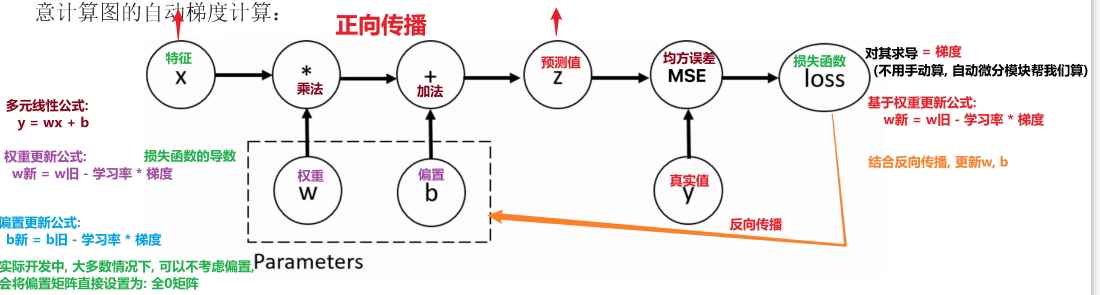

In [1]:
import torch
import numpy as np

## （1）张量的基本计算
pytorch不支持向量张量对向量张量的求导,只支持标量张量对向量张量的求导. 且大多数是浮点型
- x如果是张量,y必须是标量(一个值)才可以进行求导
- 计算梯度: `y.backward()`, y是一个标量
- 获取x点的梯度值: `x.grad`, 会累加上一次的梯度值


requires_grad=: 默认为 False, 不会自动计算梯度； 为 True的话是将自动计算的梯度值保存到 grad中

### 标量张量的计算

In [6]:
# 1. 定义变量，记录初始的权重 w（旧） 
w = torch.tensor(10, requires_grad=True, dtype=torch.float32)

# 2. 定义损失变量，表示损失函数
loss = 2 * w ** 2     

# 3. 查看梯度函数类型，即曲线函数类型
print(f'梯度函数类型: {type(loss.grad_fn)}') 

# 4. 计算梯度， 梯度 = 损失函数的导数，计算完毕后，会记录到 w.grad 属性中
loss.sum().backward()    # 保证 loss 是1 个变量
# loss.backward()       # 这里因为 y 本身就是标量，可以不写 sum()

# 5. 代入 权重更新公式： w新 = w旧 - 学习率 * 梯度
w.data = w.data - 0.01 * w.grad 

# 6. 打印最终结果
print(f'更新后的权重：{w}')

梯度函数类型: <class 'MulBackward0'>
更新后的权重：9.600000381469727


### 向量张量的计算

In [9]:
# 定义一个向量张量
w = torch.tensor([10, 20], requires_grad=True, dtype=torch.float32)

# 定义一个损失函数
loss = 2 * w ** 2 

# 计算梯度:  w 和 loss 都是向量张量，不能进行求导， 需要将 y 转换成标量张量  -- > y.sum()
y.sum().backward()

# 打印 w 的梯度
print('w.grad: ', x.grad)

w.grad:  tensor(40.)


## （2）梯度下降法求最优解
- 梯度下降法公式： w = w - r * grad (r 是学习率，gard是梯度值）
- 清空上一次梯度值： x.grad.zero_()

In [16]:
# 求 y = x**2 + 20 的极小值，并打印 y 是最小值时 w 的值（梯度）

# 1. 定义点
w = torch.tensor(10, requires_grad=True, dtype=torch.float32)

# 2. 定义函数  loss = w**2 + 20
loss = w**2 + 20

# 3. 利用梯度下降法，循环迭代 100次，求最优解
print(f'开始权重初始值：{w}, (0.01 * w.grad): 无， loss: {loss}')
# 迭代100次
for i in range(1, 100):
    # 3.1 向前传播
    loss = w ** 2 + 10
    # 3.2 梯度清零
    # 第一次的时候，还没开始计算梯度，所以 w.grad = None, 要做非空判断
    if w.grad is not None: 
        w.grad.zero_()
    # 3.3 反向传播
    loss.sum().backward()

    # 3.4 梯度更新
    w.data = w.data - 0.01 * w.grad
    print(f'开始权重初始值：{w}, (0.01 * w.grad): {0.01 * w.grad:.5f} ， loss: {loss:.5f}')

# 4. 打印最终结果
print(f'最终结果 权重：{w}, 梯度: {w.grad:.5f}, loss: {loss:.5f}')

开始权重初始值：10.0, (0.01 * w.grad): 无， loss: 120.0
开始权重初始值：9.800000190734863, (0.01 * w.grad): 0.20000 ， loss: 110.00000
开始权重初始值：9.604000091552734, (0.01 * w.grad): 0.19600 ， loss: 106.04000
开始权重初始值：9.411920547485352, (0.01 * w.grad): 0.19208 ， loss: 102.23682
开始权重初始值：9.223682403564453, (0.01 * w.grad): 0.18824 ， loss: 98.58425
开始权重初始值：9.03920841217041, (0.01 * w.grad): 0.18447 ， loss: 95.07632
开始权重初始值：8.858424186706543, (0.01 * w.grad): 0.18078 ， loss: 91.70729
开始权重初始值：8.681255340576172, (0.01 * w.grad): 0.17717 ， loss: 88.47168
开始权重初始值：8.507630348205566, (0.01 * w.grad): 0.17363 ， loss: 85.36420
开始权重初始值：8.337477684020996, (0.01 * w.grad): 0.17015 ， loss: 82.37978
开始权重初始值：8.170727729797363, (0.01 * w.grad): 0.16675 ， loss: 79.51353
开始权重初始值：8.007312774658203, (0.01 * w.grad): 0.16341 ， loss: 76.76079
开始权重初始值：7.847166538238525, (0.01 * w.grad): 0.16015 ， loss: 74.11706
开始权重初始值：7.690223217010498, (0.01 * w.grad): 0.15694 ， loss: 71.57802
开始权重初始值：7.536418914794922, (0.01 * w.grad): 0.15380 ， l

## （3） 梯度计算注意点
不能将自动微分的张量转换成numpy 数组，会发生报错，可以通过 detach() 方法实现

In [22]:
# 1. 定义张量
t1 = torch.tensor([10, 20], requires_grad=True, dtype=torch.float)
print(f't1:{t1}, type:{type(t1)}')

# 2. 尝试把上述张量  --> numpy 对象
# n1 = t1.numpy()  # 报错

# 3. 解决办法： 通过 detach() 函数，拷贝一份张量，然后转换
t2 = t1.detach() 
print(f't1:{t2}, type:{type(t2)}')

# 4. 测试上述的 t1 和 t2 是否共享同一块空间
t1.data[0] = 100
print(f't1:{t1}, type:{type(t1)}')
print(f't1:{t2}, type:{type(t2)}')
print('-'*30)

# 5. 查看 t1 和 t2 谁可以自动微分
print(f't1: {t1.requires_grad}')
print(f't2: {t2.requires_grad}')
print('-'*30)


# 6. 把 t2 转换为 numpy 
n1 = t2.numpy()
print(f'n1: {n1}, type:{type(n1)}')

# 7. 最终版本
n2 = t1.detach().numpy()
print(f'n2: {n2}, type:{type(n2)}')


t1:tensor([10., 20.], requires_grad=True), type:<class 'torch.Tensor'>
t1:tensor([10., 20.]), type:<class 'torch.Tensor'>
t1:tensor([100.,  20.], requires_grad=True), type:<class 'torch.Tensor'>
t1:tensor([100.,  20.]), type:<class 'torch.Tensor'>
------------------------------
t1: True
t2: False
------------------------------
n1: [100.  20.], type:<class 'numpy.ndarray'>
n2: [100.  20.], type:<class 'numpy.ndarray'>


## （4）自动微分模块应用

In [27]:
# 1. 定义 x， 表示：特征（输入数据），假设： 2行5列， 全1矩阵
x = torch.ones(2, 5)
print(f'x: {x}')

# 2. 定义 y, 表示：标签（真实值）。假设：2行3列，全0矩阵
y = torch.zeros(2, 3)
print(f'y: {y}')

# 3. 初始化（可自动微分的）权重w 和 偏置 b
w = torch.randn(5, 3, requires_grad=True)
print(f'w:{w}')

b = torch.randn(3, requires_grad=True)
print(f'b:{b}')

# 4. 向前传播（正向传播）， 计算出预测值（z)
z = torch.matmul(x, w) + b
# z = x @ w + b 
print(f'z: {z}')

#  5. 定义损失函数
criterion = torch.nn.MSELoss()  # neual network: 神经网络
loss = criterion(z, y)
print(f'loss:{loss}')

# 6. 进行自动微分，求导，结合反向传播，更新权重
loss.backward()

# 7. 打印 w, b 用来更新的梯度
print(f'w的梯度：{w.grad}')
print(f'b的梯度：{b.grad}')

# 后续： w新 = w旧 - 学习率 * 梯度， 来更新权重

x: tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]])
y: tensor([[0., 0., 0.],
        [0., 0., 0.]])
w:tensor([[-0.7786, -0.6752,  0.8488],
        [-0.3804, -0.0465, -0.2645],
        [ 0.6535, -0.2115,  0.7607],
        [ 0.1881, -1.3686,  1.5939],
        [-0.0991, -0.0573, -1.1372]], requires_grad=True)
b:tensor([-0.8965, -0.3958, -0.1952], requires_grad=True)
z: tensor([[-1.3130, -2.7549,  1.6065],
        [-1.3130, -2.7549,  1.6065]], grad_fn=<AddBackward0>)
loss:3.9648380279541016
w的梯度：tensor([[-0.8753, -1.8366,  1.0710],
        [-0.8753, -1.8366,  1.0710],
        [-0.8753, -1.8366,  1.0710],
        [-0.8753, -1.8366,  1.0710],
        [-0.8753, -1.8366,  1.0710]])
b的梯度：tensor([-0.8753, -1.8366,  1.0710])


# 11. Pytorch 模拟线性回归模型
- 准备训练数据集
- 构建要使用的模型
- 设置损失函数和优化器
- 模型训练

numpy对象 -> 张量Tensor -> 数据集对象TensorDataset -> 数据加载器DataLoader

In [1]:
import torch
from torch.utils.data import TensorDataset    # 构造数据集对象
from torch.utils.data import DataLoader   # 数据加载器
from torch import nn   # nn 模块中有平方损失函数和假设函数
from torch import optim  # optim 模块中有优化器函数
from sklearn.datasets import make_regression    # 创建线性回归模型数据
import matplotlib.pyplot as plt    # 可视化

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [25]:
# 1. 定义函数，创建线性回归样本数据
def create_dataset(): 
    # 1. 创建数据集对象
    x, y, coef = make_regression(              # coef 为初始权重 W
        n_samples = 100,   # 100个样本点
        n_features = 1,   # 1个特征
        noise = 10,   # 噪声，噪声越大，样本点越散，噪声越小，样本点越集中
        coef = True,   # 是否返回系数，默认为False， 返回值为None 
        bias = 14.5,   # 偏置
        random_state = 3  # 随机种子，随机种子相同，输出数据相同
    )

    # 2. 将上述数据封装为张量
    x = torch.tensor(x, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)

    # 3. 返回结果
    return x, y, coef 


# 2. 定义函数，表示训练模型
def train(x, y, coef):
    # 1. 创建数据集对象，把 tensor -> 数据集对象 -> 数据加载器
    dataset = TensorDataset(x, y)
    # 2. 创建数据加载器对象
    # 参1：数据集对象， 参2：批次大小， 参3：是否打乱数据（训练集打乱，测试集不打乱）
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True)
    # 3. 创建初始的线性回归模型
    model = nn.Linear(1, 1)   # 参1：输入， 参2： 输出
    # 4. 创建损失函数对象
    criterion = nn.MSELoss()
    # 5. 创建优化器函数对象
    # 参1：模型参数，参2：学习率
    optimizer = optim.SGD(model.parameters(), lr=1e-2)

    # 6. 具体的训练过程
    # 6.1 定义变量，分别表示：训练轮数，每轮的平均损失值，训练总损失值，训练的样本数
    epochs, loss_list, total_loss, total_sample = 100, [], 0.0, 0
    # 6.2 开始训练，按轮训练
    for epoch in range(epochs):   # epoche 的值，0， 1， 2， ... 99
        # 6.3 每轮是分 批次 训练的，所以从数据加载器中 获取 批次数据
        for train_x, train_y in dataloader:
            # 6.4 模型预测
            y_pred = model(train_x)
            # 6.5 计算（每批的平均）损失值
            loss = criterion(y_pred, train_y.reshape(-1, 1))    # -1 自动计算
            
            # 6.6 计算总损失 和 样本（批次）数
            total_loss += loss.item()
            total_sample += 1
            # 6.7 梯度清零 + 反向传播 + 梯度更新
            optimizer.zero_grad()  # 梯度清零
            loss.backward()   # 反向传播，计算梯度
            optimizer.step()   # 梯度更新

        # 6.8 把本轮的（平均）损失值，添加到列表中
        loss_list.append(total_loss / total_sample)
        print(f'轮数:{epoch + 1}, 平均损失值：{total_loss / total_sample}')
    # 7. 打印（最终的）训练结果
    print(f'{epochs}轮的平均损失分别为：{loss_list}')
    print(f'模型参数，权重：{model.weight}, 偏置：{model.bias}')

    # 8 绘制损失曲线
    plt.plot(range(epochs), loss_list)   # 100轮， 每轮的平均损失值
    plt.title('损失值曲线变化图')   
    plt.grid()   # 绘制网格图
    plt.show()

    # 9. 绘制预测值和真实值的关系
    # 9.1 绘制样本点分布情况
    plt.scatter(x, y)
    # 9.2 绘制模型的预测值
    # x: 100个样本点的特征
    y_pred = torch.tensor(data = [v * model.weight + model.bias for v in x])
    # 9.3 计算真实值
    y_true = torch.tensor(data = [v * coef + 14.5 for v in x])
    # 9.4 绘制预测值和真实值的 折线图
    plt.plot(x, y_pred, color='red', label='预测值')
    plt.plot(x, y_true, color='green', label='真实值')
    # 9.5 图例，网格
    plt.legend()
    plt.grid()
    # 9.6 显示图像
    plt.show()
    

轮数:1, 平均损失值：970.3595842633929
轮数:2, 平均损失值：828.2206638881138
轮数:3, 平均损失值：738.5713428315662
轮数:4, 平均损失值：661.599987574986
轮数:5, 平均损失值：593.0629180908203
轮数:6, 平均损失值：535.7767316727411
轮数:7, 平均损失值：490.7641304950325
轮数:8, 平均损失值：451.4956178665161
轮数:9, 平均损失值：418.470334128728
轮数:10, 平均损失值：391.8598850795201
轮数:11, 平均损失值：367.95097430340655
轮数:12, 平均损失值：347.61690194266185
轮数:13, 平均损失值：328.71080578814497
轮数:14, 平均损失值：312.083866703267
轮数:15, 平均损失值：297.94592179797945
轮数:16, 平均损失值：284.9097685813904
轮数:17, 平均损失值：273.2880867068507
轮数:18, 平均损失值：262.6236439356728
轮数:19, 平均损失值：253.04233234090017
轮数:20, 平均损失值：244.350787121909
轮数:21, 平均损失值：236.760727175239
轮数:22, 平均损失值：229.43190395677246
轮数:23, 平均损失值：222.89839560348796
轮数:24, 平均损失值：217.1142126889456
轮数:25, 平均损失值：211.39790793282646
轮数:26, 平均损失值：206.38593895880732
轮数:27, 平均损失值：201.73093091369307
轮数:28, 平均损失值：197.51918975674377
轮数:29, 平均损失值：193.40984786085306
轮数:30, 平均损失值：189.4797610328311
轮数:31, 平均损失值：185.81751282863354
轮数:32, 平均损失值：182.64028973238808
轮数:33, 平

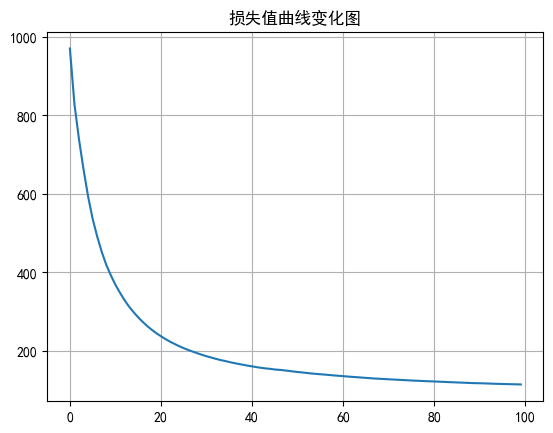

C:\Users\20633\AppData\Local\Temp\ipykernel_7272\1311223144.py:76: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_true = torch.tensor(data = [v * coef + 14.5 for v in x])


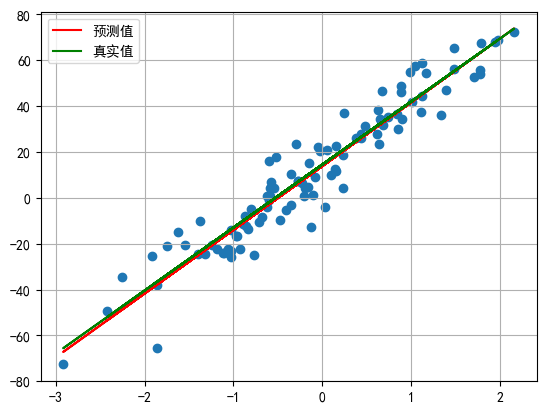

In [26]:
x, y, coef = create_dataset()
# print(f'x: {x}, y:{y}, coef:{coef}')

# 3.2 训练模型
train(x, y, coef)